# Dimension estimators

This notebook demonstrates the dimension estimators in
`nolitisea.dimension`: the correlation sum / correlation dimension, the fixed-mass information dimension and a lightweight fixed-radius correlation-sum helper.  All
examples use the x component of a Lorenz trajectory, whose attractor
dimension is about 2.05.

| # | Function | Module | Estimates |
|---|----------|--------|-----------|
| 1 | `d2` | `nolitisea.dimension.d2` | correlation sum C2, correlation dimension D2, order-2 Renyi entropy H2 |
| 2 | `c1` | `nolitisea.dimension.c1` | fixed-mass information dimension D1 |
| 3 | `correlation_integral` | `nolitisea.dimension.c2` | correlation sum at a single fixed radius |

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.dimension.c1 import c1
from nolitisea.dimension.c2 import correlation_integral
from nolitisea.dimension.d2 import d2
from nolitisea.generate.lorenz import lorenz

np.random.seed(0)
_, data = lorenz(length=2000)
x = data[:, 0]
print(f"Lorenz x series: shape={x.shape}")

Lorenz x series: shape=(2000,)


## 1. `d2` — correlation sum, dimension D2 and Renyi entropy H2

For every embedding order `m = 1 .. embed` the correlation sum

    C2(m, eps) = #{pairs with Chebyshev distance <= eps} / norm

is evaluated on a geometric ladder of radii.  Pairs whose time
separation is at most `theiler` are excluded from both the counts and
the normalisation.  The result contains the radii `eps`, the
correlation sums `c2`, the local slopes `d2` (correlation-dimension
estimates) and the order-2 Renyi entropy estimates `h2`.

The input may be 1-D (a single series) or 2-D of shape
`(n_times, n_vars)` with one column per component.

In [2]:
res = d2(
    x,
    embed=8,     # maximum embedding dimension
    delay=5,     # time delay
    theiler=50,  # exclude temporally correlated pairs
    howoften=40, # number of radii on the ladder
)
print(f"eps: {res['eps'].shape}, c2: {res['c2'].shape}, "
      f"d2: {res['d2'].shape}, h2: {res['h2'].shape}")
print(f"eligible pairs (norm): {res['norm']}")


eps: (40,), c2: (8, 40), d2: (8, 39), h2: (8, 40)
eligible pairs (norm): 1832655


### Correlation sums

The log-log plot of `C2` against the radius `eps` shows the scaling
region: with increasing embedding order `m` the curves saturate at
the attractor dimension, so they fan out and flatten.

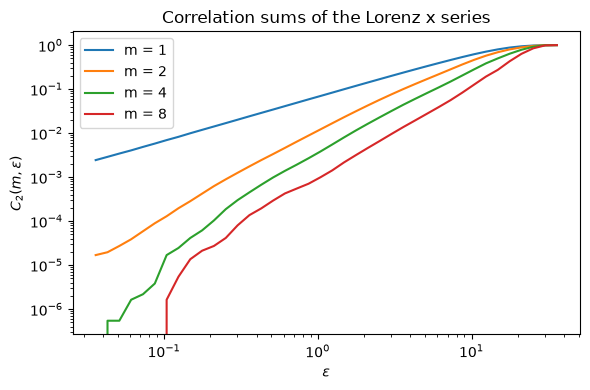

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
dims = [1, 2, 4, 8]  # embedding orders to show
for m in dims:
    ax.loglog(res["eps"], res["c2"][m - 1], label=f"m = {m}")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel(r"$C_2(m, \varepsilon)$")
ax.set_title("Correlation sums of the Lorenz x series")
ax.legend()
plt.tight_layout()
plt.show()

### Correlation dimension

The local slopes of the curves above,

    d2 = d log C2 / d log eps,

approach a plateau for large `m`; its height inside the scaling
region is the correlation-dimension estimate `D2` (about 2.05 for
the Lorenz attractor).  Averaging the slopes of the highest
embedding order over the middle part of the ladder gives a single
number.

D2 estimate (mean slope, m = 8): 2.000 (expected about 2.05)


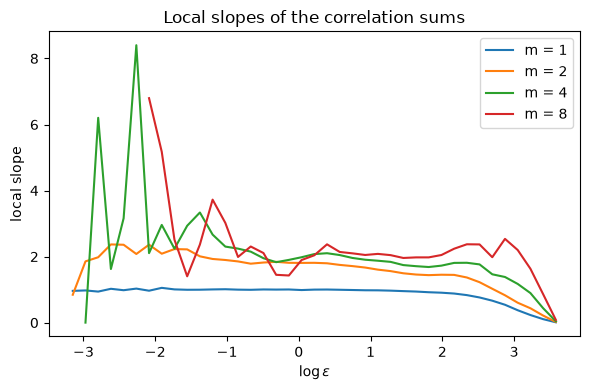

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
log_eps = np.log(res["eps"][:-1])
for m in dims:
    ax.plot(log_eps, res["d2"][m - 1], label=f"m = {m}")
ax.set_xlabel(r"$\log \varepsilon$")
ax.set_ylabel("local slope")
ax.set_title("Local slopes of the correlation sums")
ax.legend()

# Plateau estimate: average slope of the highest order in the
# middle third of the ladder (the scaling region).
slopes = res["d2"][-1]
lo, hi = slopes.size // 3, 2 * slopes.size // 3
estimate = np.nanmean(slopes[lo:hi])
print(f"D2 estimate (mean slope, m = {res['d2'].shape[0]}): "
      f"{estimate:.3f} (expected about 2.05)")

plt.tight_layout()
plt.show()

## 2. `c1` — fixed-mass information dimension D1

While `d2` grows eps balls and counts the mass inside each ball,
`c1` fixes the *mass* — a target neighbour count `k`
— and measures the radius of the `k`-th nearest neighbour.  On a
geometric ladder of masses it draws random center points and reports,
for every embedding order `m`, the geometric-mean radius `eps` and
the Grassberger-corrected `mass`.  The information dimension D1 is
the slope of `log(mass)` against `log(eps)` in the scaling region.

Neighbour search uses a Chebyshev-metric `cKDTree` with the same
Theiler-window exclusion as `d2`.

In [5]:
res1 = c1(
    x,
    embed_min=1,
    embed_max=8,  # total embedding dimensions 1..8
    delay=5,      # time delay
    theiler=50,   # Theiler window
    n_centers=500,  # random centers per ladder step (None = all)
    resolution=2.0,  # ladder points per octave
    kmax=100,     # max neighbours before the Fortran point-count clamp
    seed=0,       # reproducible center permutation
)
print(f"embedding orders: {res1['embed']}")
for m in [1, 4, 8]:
    i = m - 1
    print(f"m={m}: eps {res1['eps'][i].shape}, mass {res1['mass'][i].shape}")


embedding orders: [1 2 3 4 5 6 7 8]
m=1: eps (21,), mass (21,)
m=4: eps (21,), mass (21,)
m=8: eps (21,), mass (21,)


### Mass-radius curves

Plotting `mass` against `eps` for several embedding orders produces
curves analogous to the correlation sums: they fan out and their
slopes saturate at the information dimension D1.

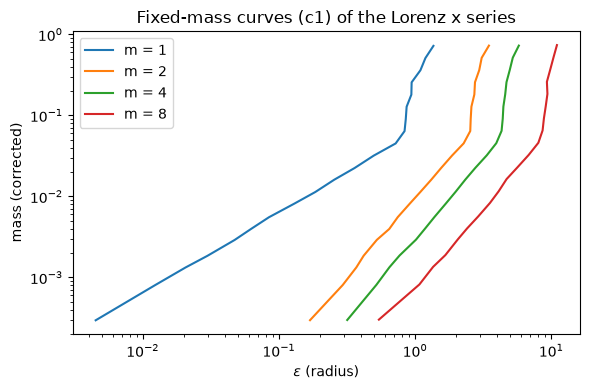

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in dims:
    i = m - 1
    ax.loglog(res1["eps"][i], res1["mass"][i], label=f"m = {m}")
ax.set_xlabel(r"$\varepsilon$ (radius)")
ax.set_ylabel("mass (corrected)")
ax.set_title("Fixed-mass curves (c1) of the Lorenz x series")
ax.legend()
plt.tight_layout()
plt.show()

### Information dimension

The local slopes `d log mass / d log eps` plateau in the scaling
region; the plateau height of the highest embedding order is the D1
estimate.  Note the ordering: the c1 ladder runs from *small* mass to
*large* mass, so the scaling region is the **early** part of the
curve.  The large-mass tail is dominated by the `kmax` point-count
clamp (slopes explode) and must be discarded.

D1 estimate (mean slope, m = 8): 2.015 (expected about 2.05)


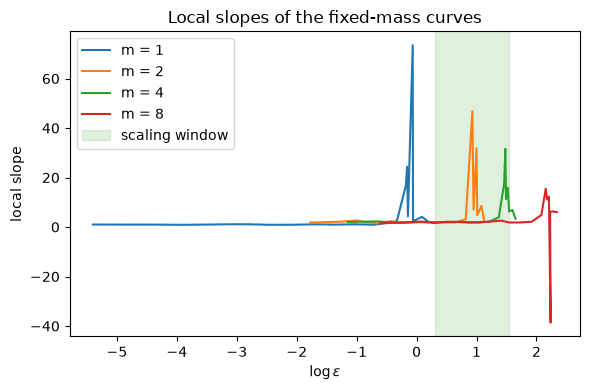

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in dims:
    i = m - 1
    le = np.log(res1["eps"][i])
    lm = np.log(res1["mass"][i])
    local_slope = np.diff(lm) / np.diff(le)
    ax.plot(le[:-1], local_slope, label=f"m = {m}")
ax.set_xlabel(r"$\log \varepsilon$")
ax.set_ylabel("local slope")
ax.set_title("Local slopes of the fixed-mass curves")
ax.legend()

# Plateau estimate for the highest embedding order: average over the
# early part of the ladder where the slopes plateau, skipping the first
# couple of points and stopping before the kmax-clamp tail.
i = res1["embed"][-1] - 1
le = np.log(res1["eps"][i])
lm = np.log(res1["mass"][i])
slopes1 = np.diff(lm) / np.diff(le)
lo, hi = 2, 10
ax.axvspan(le[lo], le[hi - 1], color="C2", alpha=0.15,
           label="scaling window")
ax.legend()
d1_est = np.nanmean(slopes1[lo:hi])
print(f"D1 estimate (mean slope, m = {res1['embed'][-1]}): "
      f"{d1_est:.3f} (expected about 2.05)")

plt.tight_layout()
plt.show()

## 3. `correlation_integral` — fixed-radius correlation sum

`correlation_integral` is a compact helper that computes the
correlation sum at a *single* fixed radius `eps` for every embedding
order up to `max_emb`.  It is the quick, single-point version of the
`d2` ladder: it builds a Chebyshev-metric `cKDTree` per embedding,
counts pairs within `eps` (Chebyshev distance), applies the Theiler
window by subtracting temporally-close pairs, and normalises by the
number of eligible unique pairs.

It returns a dict mapping embedding order `m` to the scalar
correlation sum `C2(m, eps)`.

In [8]:
eps_fixed = 0.5
c2_fixed = correlation_integral(
    x,
    max_emb=8,  # embedding orders 1..8
    delay=5,    # time delay
    theiler=50, # Theiler window
    eps=eps_fixed,  # single fixed radius
)
print(f"fixed radius eps = {eps_fixed}")
for m, c2_val in c2_fixed.items():
    print(f"  m = {m}: C2 = {c2_val:.5f}")

fixed radius eps = 0.5
  m = 1: C2 = 0.03376
  m = 2: C2 = 0.00326
  m = 3: C2 = 0.00148
  m = 4: C2 = 0.00096
  m = 5: C2 = 0.00066
  m = 6: C2 = 0.00046
  m = 7: C2 = 0.00035
  m = 8: C2 = 0.00029


### Embedding-order dependence at fixed radius

At a fixed radius, the fraction of pairs falling inside the
`eps`-ball drops with embedding order as the fixed-dimensional
trajectory occupies more volume.  Reading the curve across `m` gives
the same qualitative saturation that the `d2` ladder shows.

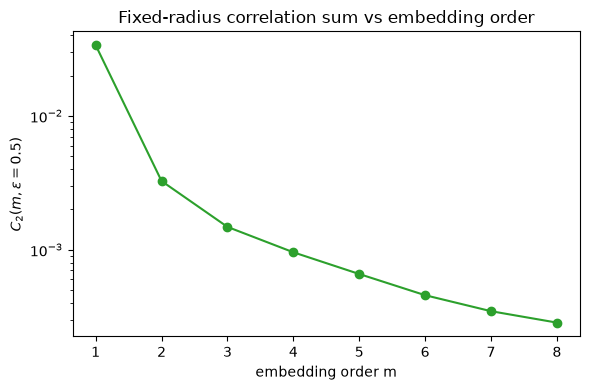

In [9]:
ms = sorted(c2_fixed)
vals = [c2_fixed[m] for m in ms]

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(ms, vals, "o-", color="C2")
ax.set_xlabel("embedding order m")
ax.set_ylabel(r"$C_2(m, \varepsilon=0.5)$")
ax.set_title("Fixed-radius correlation sum vs embedding order")
ax.set_xticks(ms)
plt.tight_layout()
plt.show()

### Radius sweep with the helper

Sweeping a few radii by hand recovers the scaling trend of the full
`d2` ladder, which is useful when only a coarse dimension check is
needed.

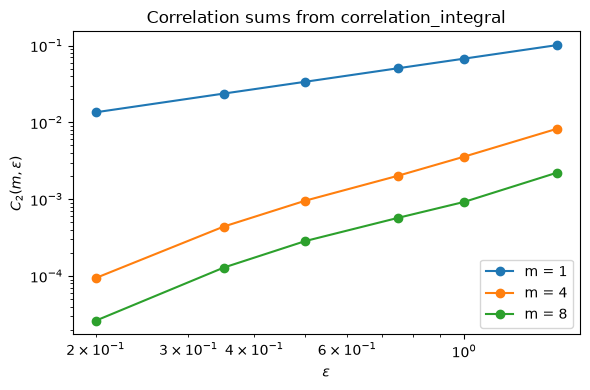

In [10]:
eps_grid = [0.2, 0.35, 0.5, 0.75, 1.0, 1.5]
c2_curves = {}
for e in eps_grid:
    c2_curves[e] = correlation_integral(
        x, max_emb=8, delay=5, theiler=50, eps=e
    )

fig, ax = plt.subplots(figsize=(6, 4))
for m in [1, 4, 8]:
    ys = [c2_curves[e][m] for e in eps_grid]
    ax.loglog(eps_grid, ys, "o-", label=f"m = {m}")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel(r"$C_2(m, \varepsilon)$")
ax.set_title("Correlation sums from correlation_integral")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

The `nolitisea.dimension` module offers three ways to estimate the
fractal dimension of an attractor from a delay embedding:

- **`d2`** — the full TISEAN correlation-sum ladder: radii `eps`,
  correlation sums `c2`, local slopes (the correlation dimension D2)
  and order-2 Renyi entropies `h2`.  Use this for a complete
  scaling-region analysis.
- **`c1`** — the fixed-mass TISEAN ladder (information dimension
  D1): fixes neighbour counts and measures radii, with Grassberger's
  finite-sample correction.  Complements `d2` (the generalized
  dimensions satisfy D1 >= D2).
- **`correlation_integral`** — a lightweight single-radius
  correlation sum per embedding order, handy for quick checks and
  coarse scans.

All three use the Chebyshev (max) norm and a Theiler window to
exclude temporally correlated pairs, consistent with the neighbour
search in `nolitisea.core.neighbors`.